In [2]:
import numpy as np
from matplotlib import matplotlib_fname
import matplotlib
import handy.my_utils as deniz
import matplotlib.pyplot as plt
import os
import mne

from EEGPreprocessor import EEGPreprocessor


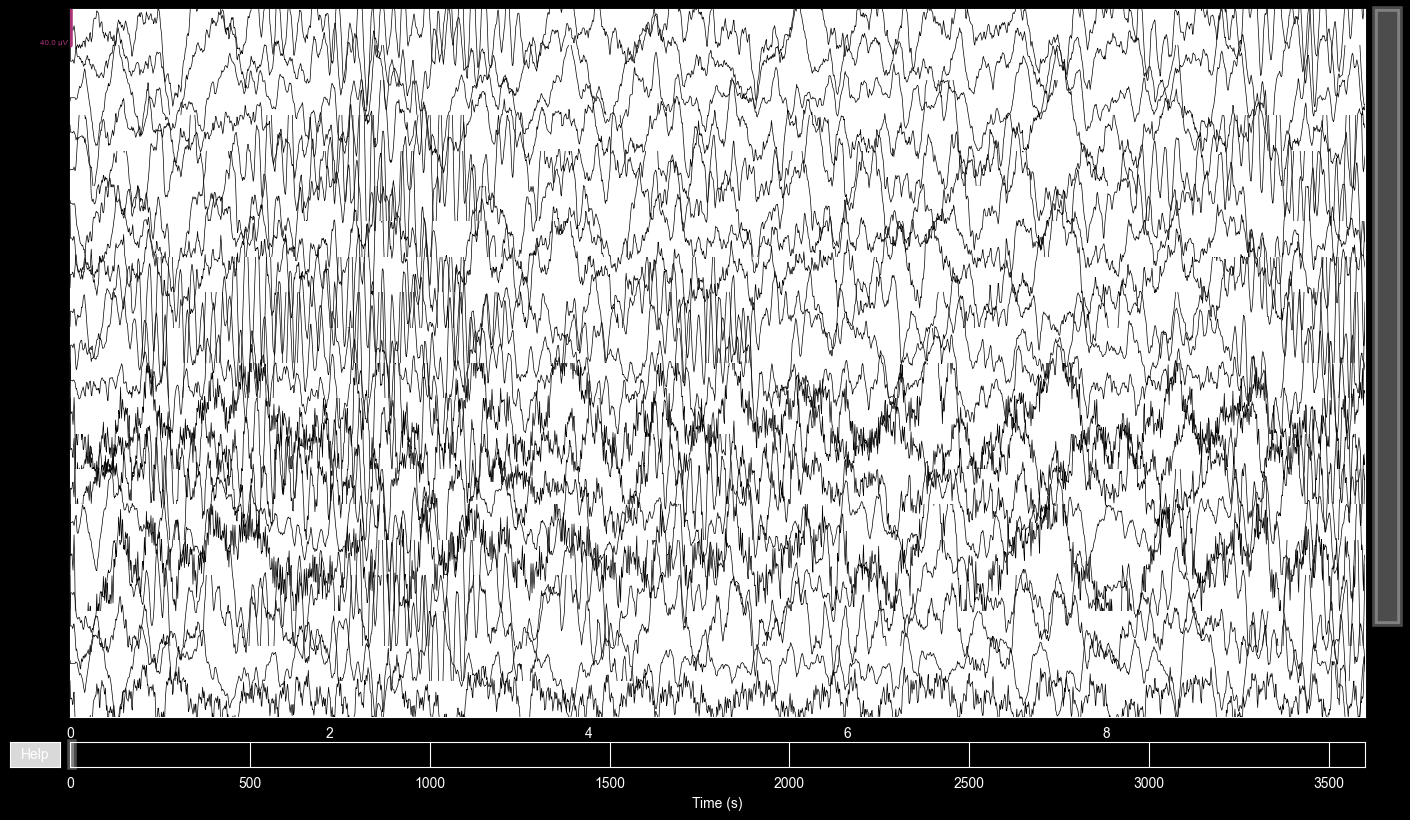

In [3]:
dataset_path = 'data-understanding/data/chb-mit'
# 1. Define the actual string path to the file
file_path = 'data-understanding/data/chb-mit/chb01/chb01_03.edf'

# 2. Load the file using MNE (this expects the string path)
raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

# 3. Visualize
raw.plot()


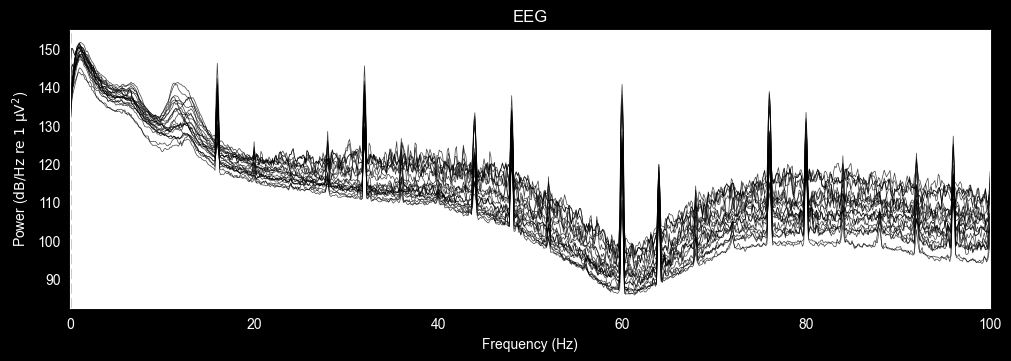

In [4]:
signals, channel_names, fs = deniz.load_edf_file('data-understanding/data/chb-mit/chb01/chb01_03.edf')

# 2. Create MNE Info object
# Note: CHB-MIT data is usually in microvolts; MNE expects Volts.
# If your loader hasn't scaled it, multiply by 1e-6
info = mne.create_info(ch_names=list(channel_names), sfreq=fs, ch_types='eeg')
raw_array = mne.io.RawArray(signals, info)

# 3. Compute PSD
# fmax=100 helps focus on the relevant brain wave frequencies
spectrum = raw_array.compute_psd(fmax=100)

# 4. Visualize
with plt.style.context({'axes.facecolor': 'white', 'axes.grid': False}):
    # Spatial colors help identify which area of the brain has more power
    fig1 = spectrum.plot(
        average=False,
        spatial_colors=True,
        picks="data"
    )
    plt.show()

# After preprocessing

In [5]:
preprocessor = EEGPreprocessor(sampling_rate= 256 ,target_sfreq=128)
preprocessor.fs

256

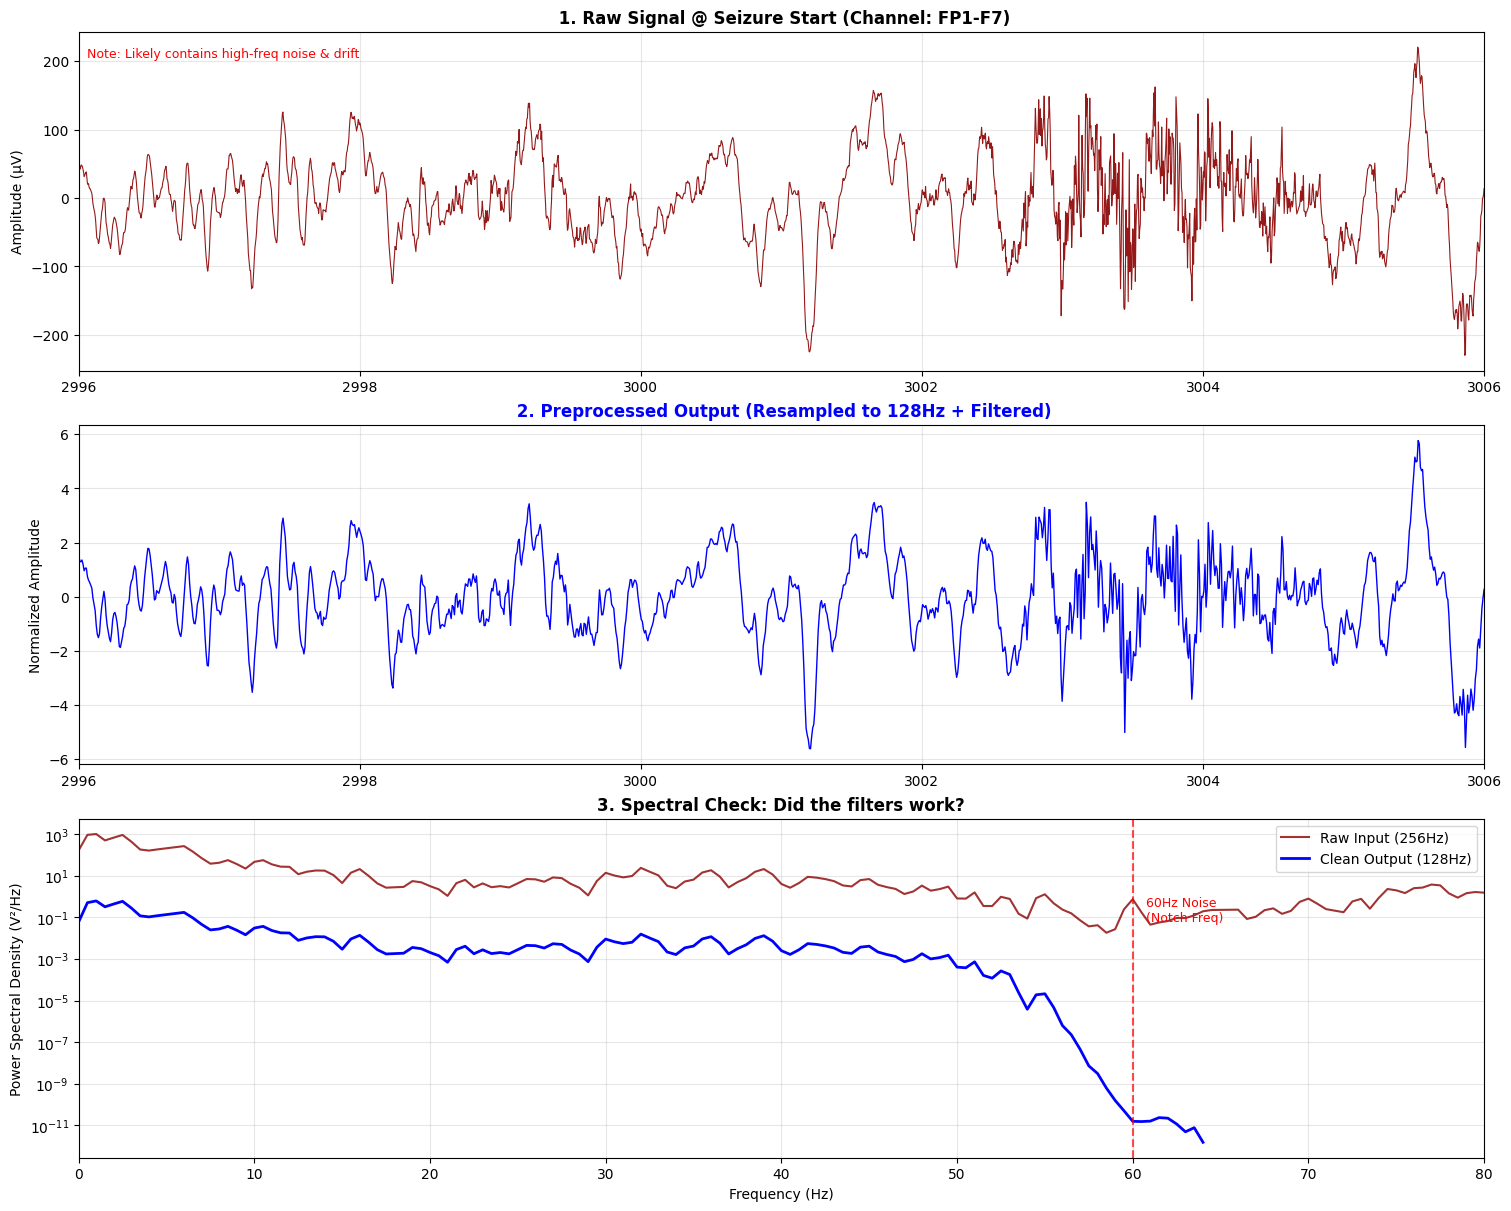

In [7]:
import matplotlib.pyplot as plt
from scipy.signal import welch
import numpy as np
import os
from EEGPreprocessor import EEGPreprocessor

# --- 1. SETUP PATHS & LOAD ---
dataset_path = 'data-understanding/data/chb-mit'
sample_file = os.path.join(dataset_path, 'chb01', 'chb01_03.edf')
preprocessor = EEGPreprocessor(sampling_rate=256, target_sfreq=128)

# Load the full data once
signals, channel_names, fs = deniz.load_edf_file(sample_file)  # Fixed: was deniz.load_edf_file

# --- 2. CONFIGURATION ---
seizure_start = 2996   # Start of seizure
plot_duration = 10     # Seconds to visualize
channel_idx = 0        # Select a channel

# Get Sampling Frequencies
fs_raw = fs                             # Original (e.g., 256 Hz)
fs_clean = preprocessor.target_sfreq   # Target (e.g., 128 Hz)

# --- 3. PREPROCESS FULL SIGNAL FIRST (avoids edge artifacts) ---
cleaned_all = preprocessor.preprocess(signals)

# --- 4. SLICING THE DATA (Focus on Seizure) ---
# Slice raw using original sampling rate
start_idx_raw = int(seizure_start * fs_raw)
end_idx_raw = int((seizure_start + plot_duration) * fs_raw)
raw_segment = signals[channel_idx, start_idx_raw:end_idx_raw]

# Slice clean using target sampling rate
start_idx_clean = int(seizure_start * fs_clean)
end_idx_clean = int((seizure_start + plot_duration) * fs_clean)
clean_segment = cleaned_all[channel_idx, start_idx_clean:end_idx_clean]

# Create Time Axes
time_raw = np.linspace(seizure_start, seizure_start + plot_duration, len(raw_segment))
time_clean = np.linspace(seizure_start, seizure_start + plot_duration, len(clean_segment))

# --- 5. VISUALIZATION ---
# Force white background so black lines are visible
plt.style.use('default')
fig, axes = plt.subplots(3, 1, figsize=(15, 12), constrained_layout=True)
fig.patch.set_facecolor('white')

# Plot 1: Raw Signal (Time Domain) — changed color to dark red so it's visible on white
axes[0].set_facecolor('white')
axes[0].plot(time_raw, raw_segment, color='darkred', linewidth=0.8, alpha=0.9)
axes[0].set_title(f' 1. Raw Signal @ Seizure Start (Channel: {channel_names[channel_idx]})', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Amplitude (μV)')
axes[0].set_xlim(seizure_start, seizure_start + plot_duration)
axes[0].grid(True, alpha=0.3)
axes[0].text(
    seizure_start, np.max(raw_segment),
    "  Note: Likely contains high-freq noise & drift",
    verticalalignment='top', color='red', fontsize=9
)

# Plot 2: Preprocessed Signal (Time Domain)
axes[1].set_facecolor('white')
axes[1].plot(time_clean, clean_segment, color='blue', linewidth=1)
axes[1].set_title(
    f' 2. Preprocessed Output (Resampled to {fs_clean}Hz + Filtered)',
    fontweight='bold', fontsize=12, color='blue'
)
axes[1].set_ylabel('Normalized Amplitude')
axes[1].set_xlim(seizure_start, seizure_start + plot_duration)
axes[1].grid(True, alpha=0.3)

# Plot 3: PSD Comparison (Frequency Domain)
f_raw, p_raw = welch(raw_segment, fs=fs_raw, nperseg=fs_raw * 2)
f_clean, p_clean = welch(clean_segment, fs=fs_clean, nperseg=fs_clean * 2)

axes[2].set_facecolor('white')
axes[2].semilogy(f_raw, p_raw, color='darkred', alpha=0.8, linewidth=1.5, label=f'Raw Input ({fs_raw}Hz)')   # Fixed: was 'k-' (invisible)
axes[2].semilogy(f_clean, p_clean, color='blue', linewidth=2, label=f'Clean Output ({fs_clean}Hz)')

axes[2].set_title('3. Spectral Check: Did the filters work?', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Power Spectral Density (V²/Hz)')
axes[2].set_xlim(0, 80)
axes[2].legend(loc='upper right')
axes[2].grid(True, which='both', alpha=0.3)

# Annotation: 60Hz Notch
notch_freq = 60
if notch_freq < max(f_raw):
    axes[2].axvline(x=notch_freq, color='red', linestyle='--', alpha=0.7)
    axes[2].text(
        notch_freq + 0.5, np.percentile(p_clean, 90),
        f' {notch_freq}Hz Noise\n (Notch Freq)',
        color='red', fontsize=9
    )

plt.show(preload=True)

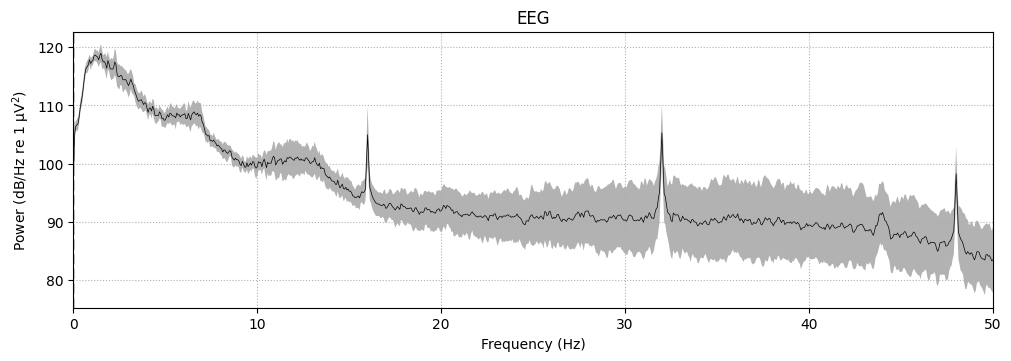

In [8]:
# Use os.path.join to handle the folder correctly
file_path = ("processed_npz_files/chb01_chb01_03.npz")

print(f"Loading file from: {file_path}")

try:
    # Load the .npz file
    preprocessed_data = np.load(file_path, allow_pickle=True)

    # 1. Extract the actual data array
    print(f"Keys in file: {preprocessed_data.files}")
    eeg_data = preprocessed_data[preprocessed_data.files[0]]

    print(f"Original Shape: {eeg_data.shape}")
    # Likely (1800, 18, 256) -> (Epochs, Channels, Time)

    # 2. FIX: Convert 3D Epochs to 2D Continuous Data
    if eeg_data.ndim == 3:
        print(" Detected 3D Epoch data. Reshaping to 2D continuous...")

        # Step A: Move Channels to the first dimension
        # Current: (Epochs, Channels, Time) -> Target: (Channels, Epochs, Time)
        eeg_data = np.transpose(eeg_data, (1, 0, 2))

        # Step B: Flatten Epochs and Time into one continuous time dimension
        # Shape becomes: (Channels, Epochs * Time)
        n_channels = eeg_data.shape[0]
        eeg_data = eeg_data.reshape(n_channels, -1)

        print(f" New 2D Shape: {eeg_data.shape}")

    # 3. Define Metadata manually
    sfreq = 128.0  # Assuming 128Hz
    ch_names = [   # Standard CHB-MIT 18 channels
        'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
        'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
        'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
        'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
        'FZ-CZ', 'CZ-PZ'
    ]

    # Create MNE info object
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

    # Create RawArray object (Now receives correct 2D data)
    raw = mne.io.RawArray(eeg_data, info)

    # --- PLOTTING SECTION ---

    # Reset any previous style to default (White)
    plt.style.use('default')

    # 1. Plot Raw Traces
    fig_raw = raw.plot(
        scalings='auto',
        duration=10,
        n_channels=len(ch_names),
        show=False,
        title="Preprocessed EEG (Reshaped from Epochs)",
        color=dict(eeg='black'),
        block=False
    )
    fig_raw.patch.set_facecolor('white')

    # 2. Plot Power Spectral Density (PSD)
    fig_psd = raw.compute_psd(fmax=50).plot(
        average=True,
        spatial_colors=True,
        show=False
    )
    fig_psd.patch.set_facecolor('white')

    # Show all plots
    plt.show()

except FileNotFoundError:
    print(f" Error: Could not find file at '{file_path}'")
except Exception as e:
    print(f" An error occurred: {e}")

In [9]:
import os
import numpy as np

file_path = "chb_mit_dataset_2seconds_epoch.npz"

if os.path.exists(file_path):
    # Load the compressed numpy file
    sample = np.load(file_path)
    X = sample['X']  # EEG Signal
    y = sample['y']  # Label

    print("=" * 40)
    print(f" File Analysis: {os.path.basename(file_path)}")
    print("=" * 40)

    # Display Dimensions
    print(f"🔹 Signal Shape (Channels, Time): {X.shape}")
    print(f"🔹 Class Label: {y}")

    # Display nonzero labels and unique labels
    print("=" * 40)
    print(f'label uniques', set(y))
    print(f'non zero count', np.count_nonzero(y))
    # Logic Check
    # 2 seconds * 128 Hz = 256 samples
    expected_shape = (18, 256)

    print("=" * 40)
    print(f" File Analysis: {os.path.basename(file_path)}")
    print("=" * 40)

    if X.shape == expected_shape:
        print(" Dimensions are correct (18 channels, 256 time points).")
    else:
        print(f"️ Unexpected dimensions! Expected {expected_shape}, got {X.shape}")
else:
    print(f" File not found: {file_path}")

 File Analysis: chb_mit_dataset_2seconds_epoch.npz
🔹 Signal Shape (Channels, Time): (12855, 18, 256)
🔹 Class Label: [1. 0. 0. ... 1. 0. 0.]
label uniques {np.float64(0.0), np.float64(1.0)}
non zero count 4285
 File Analysis: chb_mit_dataset_2seconds_epoch.npz
️ Unexpected dimensions! Expected (18, 256), got (12855, 18, 256)


In [10]:
print(X)

[[[-4.76037383e-01 -6.75039530e-01 -5.60059845e-01 ... -3.20706868e+00
   -2.82016182e+00 -2.19986010e+00]
  [ 1.32056519e-01 -2.56924272e-01 -4.86178160e-01 ... -3.32407403e+00
   -2.71664953e+00 -1.78433490e+00]
  [ 1.04028714e+00  5.23322225e-01  1.10974908e-01 ... -9.07604635e-01
   -1.51924610e+00 -1.76825154e+00]
  ...
  [-2.53599942e-01 -6.28708541e-01 -3.43370646e-01 ... -1.05152380e+00
   -1.48217928e+00 -1.47976685e+00]
  [-1.19175529e+00 -8.20256412e-01 -6.23342335e-01 ... -5.86287498e-01
   -2.30136007e-01  3.88037235e-01]
  [ 3.31849843e-01  1.75024301e-01  7.11795539e-02 ... -1.62361586e+00
   -8.49351525e-01  2.31683850e-02]]

 [[ 2.65135597e-02  3.21508706e-01 -5.06026149e-01 ...  1.92428008e-01
    1.36323735e-01  1.35476276e-01]
  [-3.24529618e-01 -7.49787033e-01  6.28975451e-01 ... -1.72226161e-01
   -5.10015905e-01 -1.48467511e-01]
  [-8.06665514e-03  8.10298085e-01 -8.04275811e-01 ...  4.46526736e-01
    9.86873150e-01  9.11322653e-01]
  ...
  [ 1.66883077e-02  1.8

In [11]:
print(set(y))

{np.float64(0.0), np.float64(1.0)}


# Plot both PSDs per channel

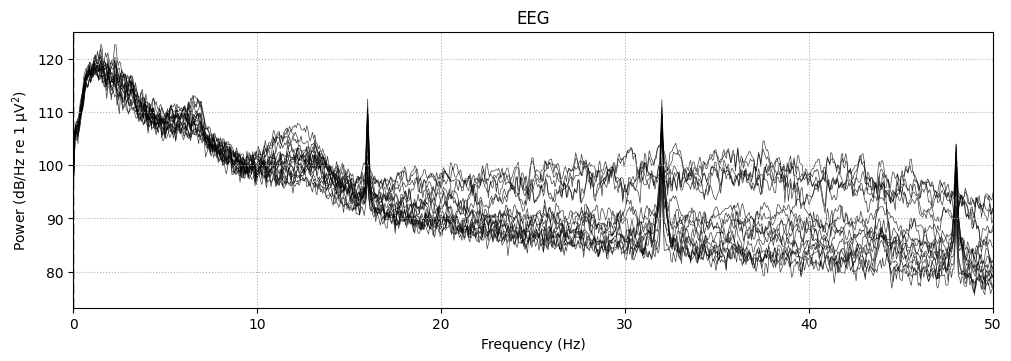

In [12]:
# This resets matplotlib to the standard white-background scientific style
plt.style.use('default')

# Generate the plot
fig_psd = raw.compute_psd(fmax=50).plot(
    average=False,
    spatial_colors=True,
    show=False
)

# Option 2: The "Manual" Fix (If Option 1 doesn't work)
# Explicitly paint the background white and text black
fig_psd.patch.set_facecolor('white') # Outer background

for ax in fig_psd.axes:
    ax.set_facecolor('white')        # Inner plot background

    # Set text and lines to black for visibility
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

    # Make borders black
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

# Finally show the plot
plt.show()

In [16]:
# Final label verification
import numpy as np
path = "processed_npz_files/chb01_chb01_03.npz"
npz = np.load(path)
npz['X']

array([[[ 1.63658547e+00,  1.76132512e+00,  1.72679460e+00, ...,
          3.03305477e-01,  4.44538206e-01,  8.56989682e-01],
        [-7.08957553e-01, -1.12731206e+00, -1.45325792e+00, ...,
          4.58298158e-03,  3.31188053e-01,  3.49091530e-01],
        [-2.28621587e-01, -4.03411388e-01, -5.28338969e-01, ...,
          3.38003546e-01,  4.31780547e-01,  1.86960220e-01],
        ...,
        [ 9.76800978e-01,  9.25873816e-01,  1.16696203e+00, ...,
          2.44717509e-01, -2.84779578e-01, -1.93870381e-01],
        [ 1.29787236e-01, -5.97576201e-01, -1.28610241e+00, ...,
          5.45826077e-01,  6.15891635e-01,  4.77992952e-01],
        [-8.14674795e-01, -5.88303387e-01, -3.02262574e-01, ...,
          9.60789546e-02,  2.14570016e-01,  3.90456498e-01]],

       [[ 3.86130989e-01,  1.92271724e-01, -1.04646064e-01, ...,
          5.45378506e-01,  6.12880230e-01,  8.28166187e-01],
        [-7.58038983e-02, -5.66434450e-02, -2.33440455e-02, ...,
          4.09065664e-01,  4.63265628e

In [17]:
npz['y']


array([0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0.])

In [18]:
np.count_nonzero(npz['y'])


41

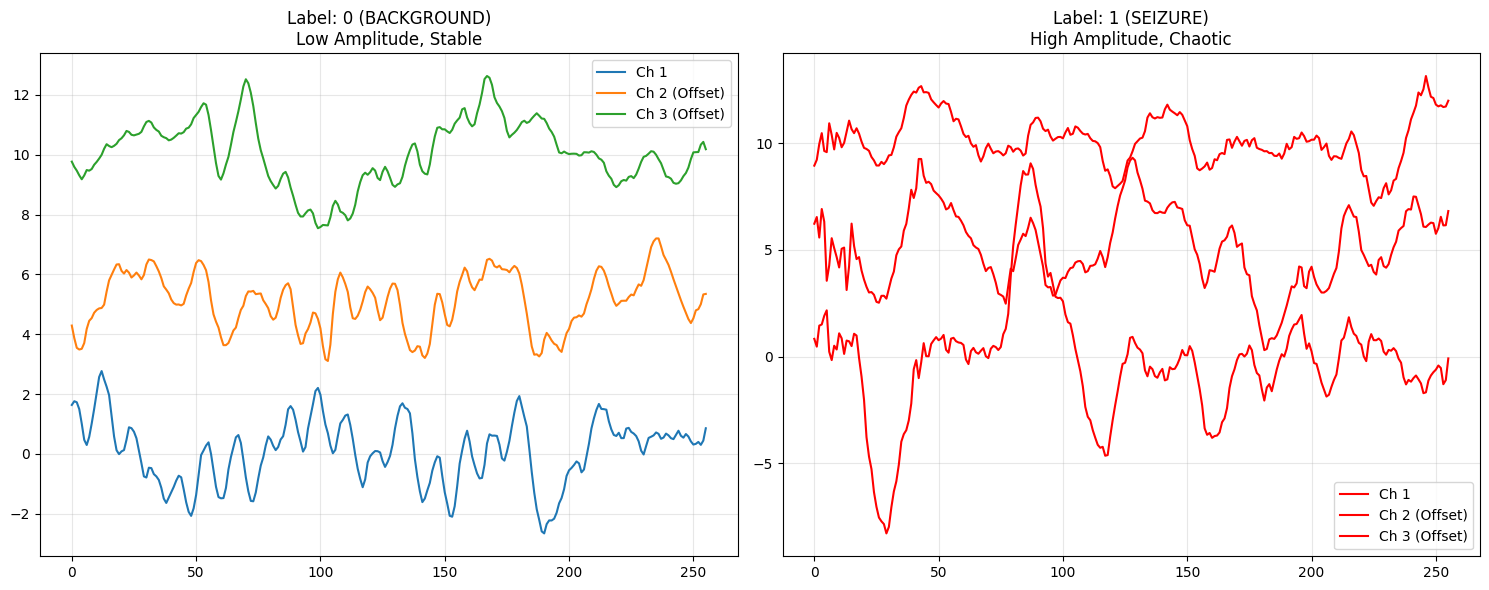

In [19]:
# Load your processed file
data = np.load("processed_npz_files/chb01_chb01_03.npz")
X = npz['X']  # Shape: (N, 18, 256)
y = npz['y']  # Shape: (N,)

# Get indices for each class
seizure_idxs = np.where(y == 1)[0]
normal_idxs = np.where(y == 0)[0]

print(f"Total Seizures: {len(seizure_idxs)}")
print(f"Total Background: {len(normal_idxs)}")

# --- PLOT VALIDATION ---
plt.figure(figsize=(15, 6))

# Plot Background (Label 0)
plt.subplot(1, 2, 1)
if len(normal_idxs) > 0:
    idx = normal_idxs[0]
    # Plot first 3 channels
    plt.plot(X[idx, 0, :], label='Ch 1')
    plt.plot(X[idx, 1, :] + 5, label='Ch 2 (Offset)')
    plt.plot(X[idx, 2, :] + 10, label='Ch 3 (Offset)')
    plt.title(f"Label: 0 (BACKGROUND)\nLow Amplitude, Stable")
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot Seizure (Label 1)
plt.subplot(1, 2, 2)
if len(seizure_idxs) > 0:
    idx = seizure_idxs[0]
    # Plot first 3 channels
    plt.plot(X[idx, 0, :], label='Ch 1', color='red')
    plt.plot(X[idx, 1, :] + 5, label='Ch 2 (Offset)', color='red')
    plt.plot(X[idx, 2, :] + 10, label='Ch 3 (Offset)', color='red')
    plt.title(f"Label: 1 (SEIZURE)\nHigh Amplitude, Chaotic")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Veriyi yükle
data_npz = np.load("processed_npz_files/chb01_chb01_03.npz")

# Dosya içindeki dizileri kontrol et (Genelde 'data' ve 'labels' olur)
print(f"About the folder: {data_npz.files}")

signals = data_npz['X']  # Şekli genellikle (Kanallar, Zaman) veya (Zaman, Kanallar)
labels = data_npz['y'] # Nöbet anlarını belirten dizi

About the folder: ['X', 'y', 'patient', 'source_file']


In [21]:
labels

array([0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0.])

In [22]:
np.count_nonzero(npz['y'])


41

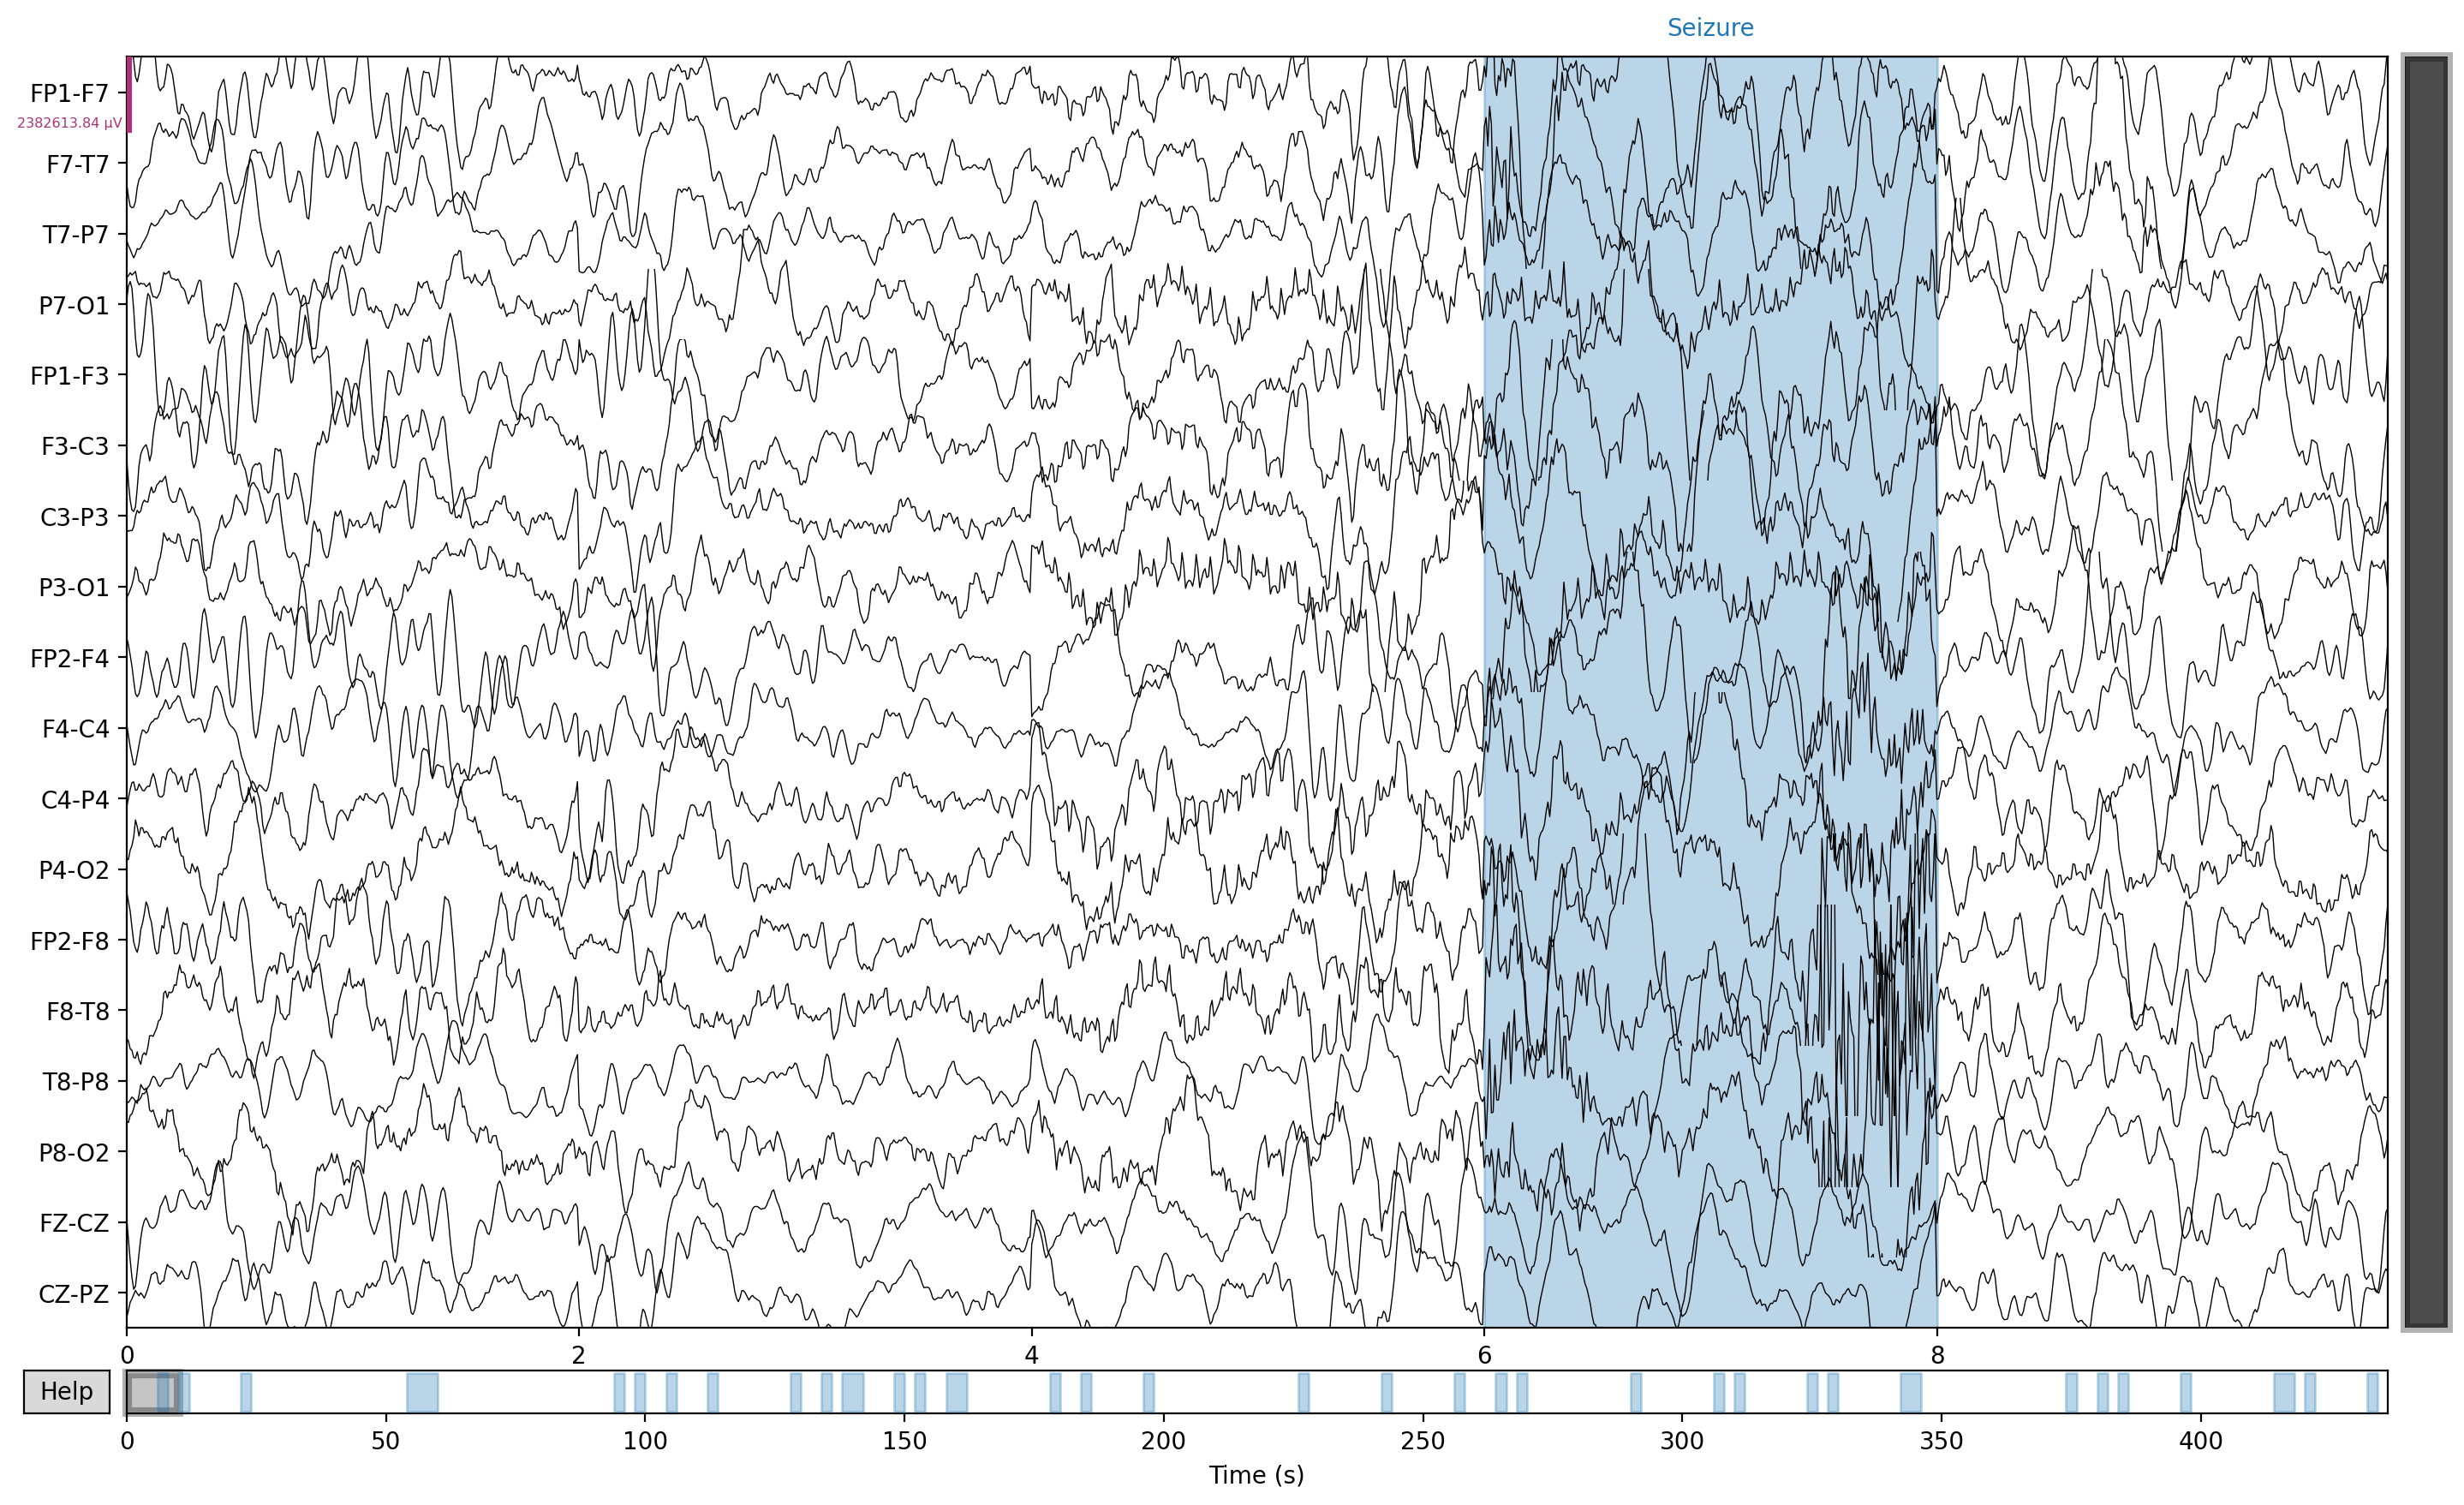

In [23]:
matplotlib.use('TkAgg')

# --- DEFINITIONS ---
FINAL_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ'
]

# 1. Load Data
# Ensure the path is correct
data_npz = np.load("processed_npz_files/chb01_chb01_03.npz")
signals = data_npz['X']   # Shape: (Epochs, 18, 256)
labels = data_npz['y']    # Shape: (Epochs,)

# 2. Reshape Data (Concatenate Epochs)
# (Epochs, Channels, Times) -> (Channels, Epochs * Times)
n_epochs, n_channels, n_times = signals.shape

# Safety Check: Ensure data channels match name list length
if n_channels != len(FINAL_CHANNELS):
    raise ValueError(f"Data has {n_channels} channels but list has {len(FINAL_CHANNELS)}")

# Transpose to (Channels, Epochs, Times) then flatten the last two dims
signals_reshaped = signals.transpose(1, 0, 2).reshape(n_channels, -1)

# 3. Create MNE Info Object
sfreq = 128
# Use the specific channel names here instead of the loop
info = mne.create_info(ch_names=FINAL_CHANNELS, sfreq=sfreq, ch_types='eeg')

# 4. Create Raw Object
raw = mne.io.RawArray(signals_reshaped, info)

# 5. Prepare Annotations (Seizure Labels)
# Expand labels: Repeat the label for every time point in the window (256 samples)
full_labels_per_sample = np.repeat(labels, n_times)

# Find transitions (0->1 is start, 1->0 is end)
diff = np.diff(full_labels_per_sample, prepend=0)

# Get onset times (in seconds)
onsets = np.where(diff > 0)[0] / sfreq
offsets = np.where(diff < 0)[0] / sfreq

# Handle edge case: if seizure is active at the very end of the file
if len(offsets) < len(onsets):
    offsets = np.append(offsets, signals_reshaped.shape[1] / sfreq)

durations = offsets - onsets

if len(onsets) > 0:
    annot = mne.Annotations(onset=onsets, duration=durations, description=['Seizure'] * len(onsets))
    raw.set_annotations(annot)
    print(f" Added {len(onsets)} seizure annotations.")
else:
    print(" No seizures found in this file.")

# 6. Visualize
# scalings='auto' helps fit the data to the window
raw.plot(scalings='auto', block=True, title="chb01_03 - Preprocessed Data")